In [1]:
import pandas as pd
import numpy as np

from scipy.stats import ttest_ind, f_oneway, pearsonr
import matplotlib.pyplot as plt


In [2]:
orders = pd.read_csv("orders.csv")
customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")
shipping = pd.read_csv("shipping.csv")


In [3]:
df = orders.merge(customers, on="Customer_ID", how="left") \
           .merge(products, on="Product_ID", how="left") \
           .merge(shipping, on="Order_ID", how="left")

df.head()


,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Sales,Discount,Gender,Age,Region,Category,Price,Delivery_Days
0,1001,2024-01-01,4,104,4,8487,15,Male,38,West,Electronics,4988,9
1,1002,2024-01-02,30,107,2,7299,15,Female,43,West,Electronics,1363,7
2,1003,2024-01-03,37,104,1,13056,5,Female,25,West,Electronics,4988,4
3,1004,2024-01-04,23,109,2,4965,10,Female,21,West,Home,1063,3
4,1005,2024-01-05,39,101,3,1135,15,Male,40,South,Electronics,1002,5


In [4]:
df["Discount_Flag"] = np.where(df["Discount"] > 0, "Discounted", "No_Discount")


In [5]:
purchase_count = df.groupby("Customer_ID")["Order_ID"].nunique()
df["Customer_Type"] = df["Customer_ID"].map(
    lambda x: "Repeat" if purchase_count[x] > 1 else "New"
)


Hypothesis 1
Do discounts increase average order value?
H₀: Discounts do not affect AOV
H₁: Discounts increase AOV

In [6]:
discounted = df[df["Discount"] > 0]["Sales"]
non_discounted = df[df["Discount"] == 0]["Sales"]

t_stat, p_value = ttest_ind(discounted, non_discounted, equal_var=False)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

if p_value < 0.05:
    print("Reject Null Hypothesis → Discounts impact AOV")
else:
    print("Fail to Reject Null Hypothesis")


T-Statistic: 0.6434133881632634
P-Value: 0.5221116494127196
Fail to Reject Null Hypothesis


Hypothesis 2
Do repeat customers spend more than new customers?

In [7]:
repeat_sales = df[df["Customer_Type"] == "Repeat"]["Sales"]
new_sales = df[df["Customer_Type"] == "New"]["Sales"]

t_stat, p_value = ttest_ind(repeat_sales, new_sales, equal_var=False)

print("P-Value:", p_value)

if p_value < 0.05:
    print("Reject H₀ → Repeat customers spend more")
else:
    print("Fail to Reject H₀")


P-Value: 0.9896324702205561
Fail to Reject H₀


Hypothesis 3
Does delivery time affect repeat purchases?

In [8]:
repeat_flag = df["Customer_Type"].map({"Repeat": 1, "New": 0})

corr, p_value = pearsonr(df["Delivery_Days"], repeat_flag)

print("Correlation:", corr)
print("P-Value:", p_value)

if p_value < 0.05:
    print("Reject H₀ → Delivery time impacts repeat purchases")
else:
    print("Fail to Reject H₀")


Correlation: -0.11280634608955946
P-Value: 0.2638010929774276
Fail to Reject H₀


Hypothesis 4
Does product category affect revenue? (ANOVA)

In [9]:
categories = df["Category"].unique()

sales_by_category = [
    df[df["Category"] == cat]["Sales"] for cat in categories
]

f_stat, p_value = f_oneway(*sales_by_category)

print("F-Statistic:", f_stat)
print("P-Value:", p_value)

if p_value < 0.05:
    print("Reject H₀ → Revenue differs across categories")
else:
    print("Fail to Reject H₀")


F-Statistic: 0.04988360046397865
P-Value: 0.9513645422486283
Fail to Reject H₀


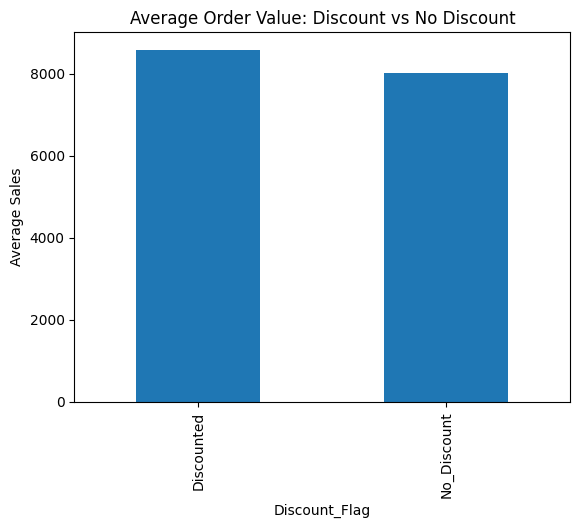

In [10]:
df.groupby("Discount_Flag")["Sales"].mean().plot(kind="bar")
plt.title("Average Order Value: Discount vs No Discount")
plt.ylabel("Average Sales")
plt.show()


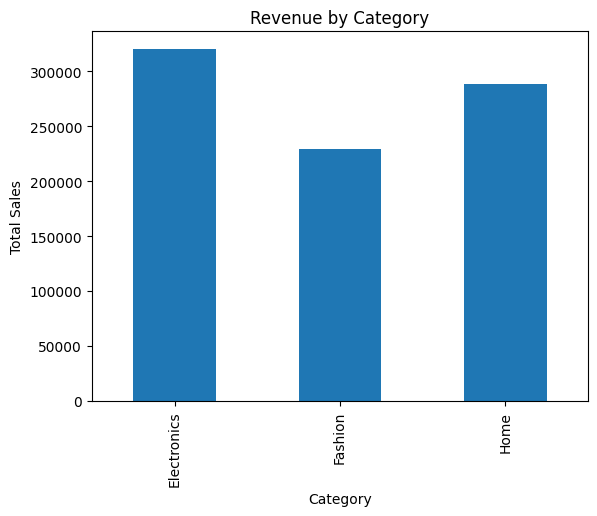

In [11]:
df.groupby("Category")["Sales"].sum().plot(kind="bar")
plt.title("Revenue by Category")
plt.ylabel("Total Sales")
plt.show()
